# Módulo 3 — Análise de Relevo e Declividade

O relevo determina praticamente tudo numa propriedade rural: onde a água escoa, onde há risco de erosão, onde dá pra mecanizar, e até o microclima de cada trecho.

**Dados:** SRTM (Shuttle Radar Topography Mission) — resolução de 30 metros, cobertura global.

**Análises:**
1. **Elevação** — altitude de cada ponto do sítio (metros acima do nível do mar)
2. **Declividade** — inclinação do terreno em graus
3. **Classificação EMBRAPA** — aptidão do terreno por classe de declividade
4. **Hillshade** — sombreamento 3D do relevo
5. **Aspecto** — orientação da encosta (norte, sul, leste, oeste)

**Classificação de declividade (EMBRAPA):**
| Classe | Graus | Aptidão |
|--------|-------|---------|
| Plano | 0-3° | Mecanização total |
| Suave ondulado | 3-8° | Mecanização com restrições |
| Ondulado | 8-20° | Uso restrito, pastagem |
| Forte ondulado | 20-45° | Preservação recomendada |
| Montanhoso | >45° | Preservação obrigatória |

In [1]:
import sys
sys.path.append("..")

import folium
import matplotlib.pyplot as plt
import numpy as np

from src.config import SITIO_CENTER
from src.geo_utils import carregar_sitio
from src.ee_utils import (
    inicializar_ee,
    carregar_geometria_sitio,
    carregar_elevacao,
    calcular_declividade,
    calcular_aspecto,
    calcular_hillshade,
    classificar_declividade,
    obter_estatisticas_elevacao,
    obter_estatisticas_declividade,
    calcular_percentual_classes_declividade,
    gerar_url_tile_elevacao,
    gerar_url_tile_declividade,
    gerar_url_tile_hillshade,
    gerar_url_tile_classes_declividade,
)

inicializar_ee()
geometria = carregar_geometria_sitio()
gdf_sitio = carregar_sitio()
print("Earth Engine inicializado.")

Earth Engine inicializado.


## 1. Dados de elevação e derivados

In [2]:
# Carregar e processar dados de relevo
elevacao = carregar_elevacao(geometria)
declividade = calcular_declividade(elevacao)
aspecto = calcular_aspecto(elevacao)
hillshade = calcular_hillshade(elevacao)
classes = classificar_declividade(declividade)

# Estatísticas de elevação
stats_elev = obter_estatisticas_elevacao(elevacao, geometria)
print("--- Elevação ---")
print(f"Mínima:  {stats_elev['minimo']:.0f} m")
print(f"Média:   {stats_elev['media']:.0f} m")
print(f"Máxima:  {stats_elev['maximo']:.0f} m")
print(f"Desnível: {stats_elev['desnivel']:.0f} m")

# Estatísticas de declividade
stats_decl = obter_estatisticas_declividade(declividade, geometria)
print(f"\n--- Declividade ---")
print(f"Mínima: {stats_decl['minimo']:.1f}°")
print(f"Média:  {stats_decl['media']:.1f}°")
print(f"Máxima: {stats_decl['maximo']:.1f}°")

# Classes de declividade (EMBRAPA)
pct_classes = calcular_percentual_classes_declividade(classes, geometria)
print(f"\n--- Classes de Aptidão (EMBRAPA) ---")
for classe, pct in pct_classes.items():
    print(f"{classe}: {pct}%")

--- Elevação ---
Mínima:  656 m
Média:   680 m
Máxima:  708 m
Desnível: 52 m



--- Declividade ---
Mínima: 7.0°
Média:  17.3°
Máxima: 26.0°



--- Classes de Aptidão (EMBRAPA) ---
Suave ondulado (3-8°): 19.5%
Ondulado (8-20°): 43.7%
Forte ondulado (20-45°): 36.8%


## 2. Mapa interativo do relevo

Mapa com 5 camadas alternáveis:
- **Elevação** — azul (baixo) a vermelho (alto)
- **Declividade** — verde (plano) a vermelho (íngreme)
- **Classes EMBRAPA** — aptidão agrícola por declividade
- **Hillshade** — sombreamento 3D do terreno
- **Satélite** — referência visual

In [3]:
# Gerar URLs de tile
url_elev = gerar_url_tile_elevacao(elevacao, stats_elev["minimo"], stats_elev["maximo"])
url_decl = gerar_url_tile_declividade(declividade)
url_hill = gerar_url_tile_hillshade(hillshade)
url_classes = gerar_url_tile_classes_declividade(classes)

# Criar mapa
mapa_relevo = folium.Map(location=SITIO_CENTER, zoom_start=17, tiles=None)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Satélite", attr="Esri",
).add_to(mapa_relevo)

folium.TileLayer(tiles=url_hill, name="Relevo 3D (Hillshade)",
                 attr="SRTM/NASA", overlay=False).add_to(mapa_relevo)

folium.TileLayer(tiles=url_elev, name="Elevação (metros)",
                 attr="SRTM/NASA", overlay=False).add_to(mapa_relevo)

folium.TileLayer(tiles=url_decl, name="Declividade (graus)",
                 attr="SRTM/NASA", overlay=False).add_to(mapa_relevo)

folium.TileLayer(tiles=url_classes, name="Aptidão Agrícola (EMBRAPA)",
                 attr="SRTM/NASA + EMBRAPA", overlay=False).add_to(mapa_relevo)

# Contorno do sítio
folium.GeoJson(gdf_sitio.to_json(), name="Limite do Sítio",
               style_function=lambda x: {"fillColor":"transparent","color":"#FFD700","weight":3,"fillOpacity":0}).add_to(mapa_relevo)

# Marcador
folium.CircleMarker(
    location=SITIO_CENTER, radius=6, color="#FFD700", fill=True,
    fill_color="#228B22", fill_opacity=0.8,
    popup=(
        f"<b>Relevo do Sítio</b><br>"
        f"Elevação: {stats_elev['minimo']:.0f}m - {stats_elev['maximo']:.0f}m<br>"
        f"Desnível: {stats_elev['desnivel']:.0f}m<br>"
        f"Declividade média: {stats_decl['media']:.1f}°"
    ),
).add_to(mapa_relevo)

folium.LayerControl().add_to(mapa_relevo)
mapa_relevo

## 3. Gráfico de classes de aptidão

Distribuição percentual da área do sítio por classe de declividade (EMBRAPA).

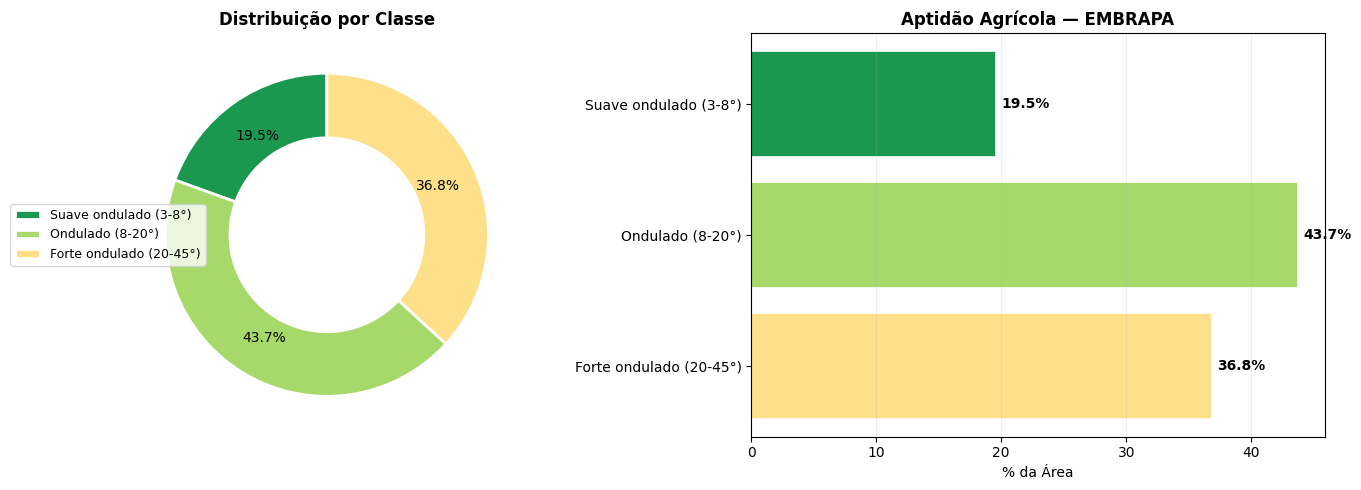

In [4]:
# Gráfico de classes de aptidão
cores_classes = ["#1a9850", "#a6d96a", "#fee08b", "#f46d43", "#d73027"]
labels = list(pct_classes.keys())
valores = list(pct_classes.values())
cores = cores_classes[:len(labels)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pizza
wedges, texts, autotexts = ax1.pie(
    valores, labels=None, colors=cores, autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)
ax1.legend(labels, loc="center left", bbox_to_anchor=(-0.3, 0.5), fontsize=9)
ax1.set_title("Distribuição por Classe", fontsize=12, fontweight="bold")

# Barras horizontais
bars = ax2.barh(labels, valores, color=cores, edgecolor="white", linewidth=0.5)
ax2.set_xlabel("% da Área")
ax2.set_title("Aptidão Agrícola — EMBRAPA", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.2, axis="x")
for bar, val in zip(bars, valores):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=10, fontweight="bold")
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("../data/classes_declividade.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Exportar

Salvamos o mapa e os dados para integração no relatório.

In [5]:
mapa_relevo.save("../data/mapa_relevo.html")
print("Mapa de relevo salvo em data/mapa_relevo.html")

Mapa de relevo salvo em data/mapa_relevo.html
